# xor model (from robert paper) visualization

In [1]:
import os, scipy.io 
import numpy as np 
# %matplotlib ipympl
import matplotlib.pyplot as plt 
from mpl_toolkits.mplot3d import axes3d

### load model

In [2]:
import sys 
sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils')
import load_data as ld

2025-10-09 17:09:01.713632: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-09 17:09:01.726504: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-10-09 17:09:01.739779: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-10-09 17:09:01.743719: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-10-09 17:09:01.756184: I tensorflow/core/platform/cpu_feature_guar

In [20]:
model_dir = '/home/nuttidalab/Documents/renee/jitter_models/models/xor/P_rec_0.2_Taus_4.0_25.0'
model_list = ld.find_files_keywords(model_dir, ['Jitter_10_10', '.mat'])
# remove directories 
model_list = [m.split('/')[-1] for m in model_list]
model_list.sort()

print(model_list)
print(len(model_list))

['Task_xor_N_200_Jitter_10_10_2025_10_09_160044.mat', 'Task_xor_N_200_Jitter_10_10_2025_10_09_160147.mat', 'Task_xor_N_200_Jitter_10_10_2025_10_09_160548.mat', 'Task_xor_N_200_Jitter_10_10_2025_10_09_161657.mat', 'Task_xor_N_200_Jitter_10_10_2025_10_09_163726.mat', 'Task_xor_N_200_Jitter_10_10_2025_10_09_163742.mat', 'Task_xor_N_200_Jitter_10_10_2025_10_09_163812.mat', 'Task_xor_N_200_Jitter_10_10_2025_10_09_165102.mat', 'Task_xor_N_200_Jitter_10_10_2025_10_09_165551.mat', 'Task_xor_N_200_Jitter_10_10_2025_10_09_170029.mat', 'Task_xor_N_200_Jitter_10_10_2025_10_09_171137.mat', 'Task_xor_N_200_Jitter_10_10_2025_10_09_171612.mat', 'Task_xor_N_200_Jitter_10_10_2025_10_09_175257.mat']
13


In [21]:
perfs = []
train_trials = []
for i, model_name in enumerate(model_list):
    model_path = os.path.join(model_dir, model_name)
    model_data = scipy.io.loadmat(model_path)
    perfs.append(model_data['eval_perf_mean'][0][0])
    train_trials.append(model_data['tr'][0][0])
    print(f'Model: {model_name}, Test perf: {perfs[i]}, Train trials: {train_trials[i]}')

Model: Task_xor_N_200_Jitter_10_10_2025_10_09_160044.mat, Test perf: 0.99, Train trials: 9201
Model: Task_xor_N_200_Jitter_10_10_2025_10_09_160147.mat, Test perf: 0.96, Train trials: 9501
Model: Task_xor_N_200_Jitter_10_10_2025_10_09_160548.mat, Test perf: 0.96, Train trials: 13301
Model: Task_xor_N_200_Jitter_10_10_2025_10_09_161657.mat, Test perf: 1.0, Train trials: 11101
Model: Task_xor_N_200_Jitter_10_10_2025_10_09_163726.mat, Test perf: 0.96, Train trials: 21901
Model: Task_xor_N_200_Jitter_10_10_2025_10_09_163742.mat, Test perf: 0.98, Train trials: 25201
Model: Task_xor_N_200_Jitter_10_10_2025_10_09_163812.mat, Test perf: 1.0, Train trials: 14501
Model: Task_xor_N_200_Jitter_10_10_2025_10_09_165102.mat, Test perf: 0.97, Train trials: 9001
Model: Task_xor_N_200_Jitter_10_10_2025_10_09_165551.mat, Test perf: 0.96, Train trials: 11801
Model: Task_xor_N_200_Jitter_10_10_2025_10_09_170029.mat, Test perf: 1.0, Train trials: 15501
Model: Task_xor_N_200_Jitter_10_10_2025_10_09_171137.mat

In [19]:
# remove models with less than 95% performance

import os

def remove_low_perf_models(model_list, model_dir, perf_thresh=0.95):
    for i, model_name in enumerate(model_list):
        model_path = os.path.join(model_dir, model_name)
        model_data = scipy.io.loadmat(model_path)
        perf = model_data['eval_perf_mean'][0][0]
        if perf < perf_thresh:
            print(f'Removing model {model_name} with performance {perf}')
            os.remove(model_path)
    return 

remove_low_perf_models(model_list, model_dir, perf_thresh=0.95)

Removing model Task_xor_N_200_Jitter_10_10_2025_10_09_183857.mat with performance 0.0


In [2]:
model_dir = '/home/nuttidalab/Documents/renee/jitter_models/models/xor/P_rec_0.2_Taus_4.0_25.0'
model_fname = 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_04_163652'
mat_data = scipy.io.loadmat(os.path.join(model_dir, model_fname))

In [3]:
for keys in mat_data.keys():
    print(keys)

__header__
__version__
__globals__
x0
r0
w0
taus_gaus0
w_in0
u
o
w
x
target
w_out
r
m
som_m
N
exc
inh
w_in
b_out
som_N
losses
taus
eval_perf_mean
eval_loss_mean
eval_os
eval_labels
taus_gaus
tr
activation


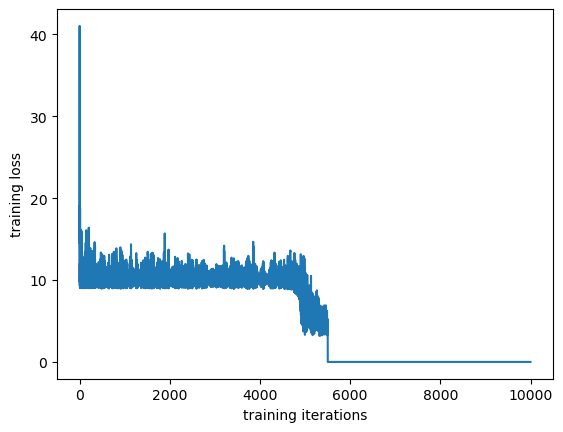

In [6]:
plt.figure()
plt.plot(mat_data['losses'].T)
plt.ylabel('training loss')
plt.xlabel('training iterations')
plt.show()

(2, 500)


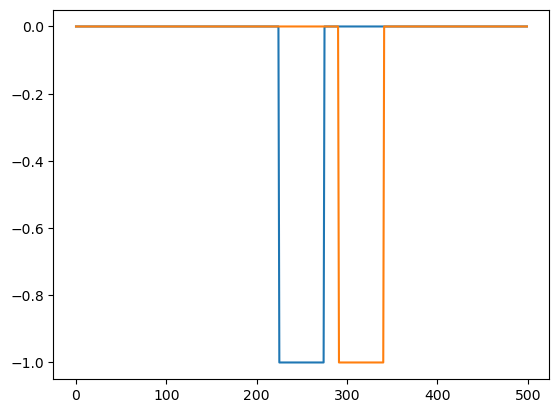

[]
[]


In [7]:
print(mat_data['u'].shape)
plt.plot(mat_data['u'].T)
plt.show()
print(np.where(mat_data['u'][0,:] > 0)[0])
print(np.where(mat_data['u'][1,:] > 0)[0])

### Visualize outputs

In [8]:
mat_data['eval_os'].shape

(100, 499)

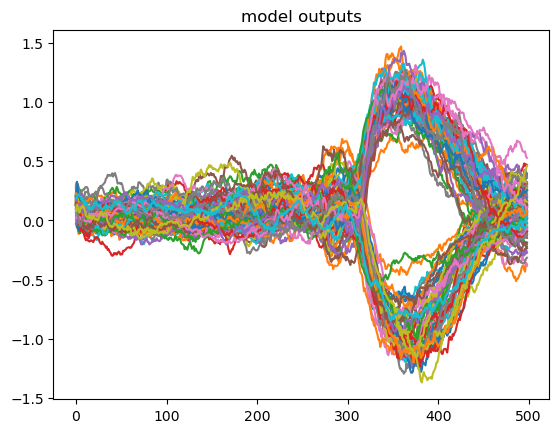

In [9]:
plt.figure()
plt.plot(np.transpose(mat_data['eval_os'][:,]))
plt.title('model outputs')
plt.show()

### get final variables

In [10]:
w = mat_data['w']
m = mat_data['m']
final_w = np.matmul(w, m)
taus_gaus = mat_data['taus_gaus']
taus = mat_data['taus'].flatten()
taus_sig = (1/(1+np.exp(-taus_gaus))*(taus[1] - taus[0])) + taus[0]

In [11]:
exc = mat_data['exc']
exc_ind = np.where(exc == 1)[0]
inh = mat_data['inh']
inh_ind = np.where(inh == 1)[0]
print(inh_ind)

[  0   2   8  17  19  27  34  41  47  48  62  65  66  69  71  72  73  74
  85  91  97  98 106 112 115 116 120 122 125 126 128 138 145 147 160 162
 173 177 187 189 190 193 199]


### model eval

In [13]:
import sys
sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/rate')
from model import generate_input_stim_xor

2025-08-04 17:41:58.107144: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-04 17:41:58.115241: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-08-04 17:41:58.122356: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-08-04 17:41:58.125576: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-08-04 17:41:58.134393: I tensorflow/core/platform/cpu_feature_guar

Instructions for updating:
non-resource variables are not supported in the long term


In [18]:
import model
settings = {
        'T': 500, # trial duration (in steps)
        'stim_on': 200, # input stim onset (in steps)
        'stim_dur': 50, # input stim duration (in steps)
        'delay': 10, # delay b/w the two stimuli (in steps)
        'DeltaT': 1, # sampling rate
        'taus': 20, # decay time-constants (in steps)
        'task': 'xor', # task name
        }

outputs = []
perfs = np.zeros(100)
for i in range(100):
    jitter_onset = 50
    jitter_delay = 5
    settings_jitter = settings.copy()
    settings_jitter['stim_on'] = settings['stim_on'] + np.random.randint(-jitter_onset, jitter_onset+1)
    if jitter_delay > 0:
        settings_jitter['delay'] = settings['delay'] + np.random.randint(-jitter_delay, jitter_delay+1)

    u, label = generate_input_stim_xor(settings_jitter)
    _, _, o, _ = model.eval_tf(model_dir=f'{model_dir}/{model_fname}', settings=settings_jitter, u=u)
    outputs.append(o)

    resp_onset = settings_jitter['stim_on'] + 2*settings_jitter['stim_dur'] + settings_jitter['delay']
    eval_amp_threshold = 0.7
    if label == 'same':
        if np.max(o[resp_onset:]) > eval_amp_threshold:
            perfs[i] = 1
    else:
        if np.min(o[resp_onset:]) < -eval_amp_threshold:
            perfs[i] = 1
    

In [19]:
print(f'Performance with jittered stim onset and delay: {np.mean(perfs)*100:.2f}%')

Performance with jittered stim onset and delay: 95.00%


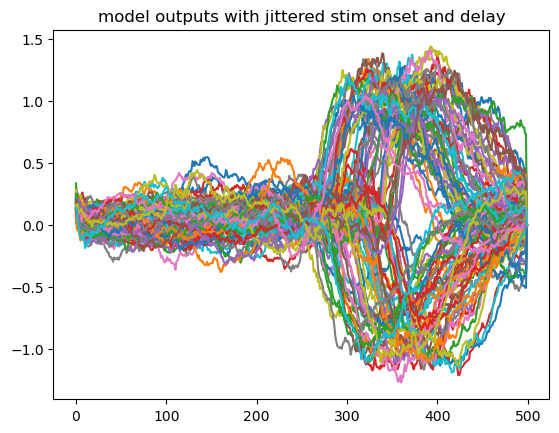

In [20]:
plt.figure()
plt.plot(np.array(outputs).T)
plt.title('model outputs with jittered stim onset and delay')
plt.show()

(200, 500)
(200, 500)
(500,)


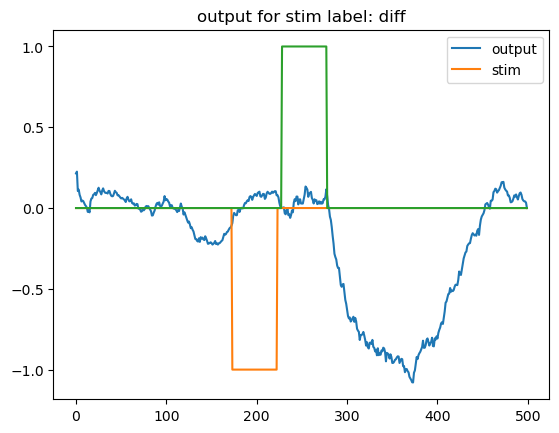

In [21]:

x, r, o, _ = model.eval_tf(model_dir=f'{model_dir}/{model_fname}', settings=settings, u=u)
print(x.shape)
print(r.shape)
print(o.shape)

plt.figure()
plt.plot(o)
plt.plot(u[0,:])
plt.plot(u[1,:])
plt.title(f'output for stim label: {label}')
plt.legend(['output','stim'])
plt.show()

#### testing on longer delays

In [31]:
# delay 50

settings = {
        'T': 500, # trial duration (in steps)
        'stim_on': 200, # input stim onset (in steps)
        'stim_dur': 50, # input stim duration (in steps)
        'delay': 50, # delay b/w the two stimuli (in steps)
        'DeltaT': 1, # sampling rate
        'taus': 20, # decay time-constants (in steps)
        'task': 'xor', # task name
        }

outputs = []
perfs = np.zeros(100)
for i in range(100):
    jitter_onset = 50
    jitter_delay = 5
    settings_jitter = settings.copy()
    settings_jitter['stim_on'] = settings['stim_on'] + np.random.randint(-jitter_onset, jitter_onset+1)
    if jitter_delay > 0:
        settings_jitter['delay'] = settings['delay'] + np.random.randint(-jitter_delay, jitter_delay+1)

    u, label = generate_input_stim_xor(settings_jitter)
    _, _, o, _ = model.eval_tf(model_dir=f'{model_dir}/{model_fname}', settings=settings_jitter, u=u)
    outputs.append(o)

    resp_onset = settings_jitter['stim_on'] + 2*settings_jitter['stim_dur'] + settings_jitter['delay']
    eval_amp_threshold = 0.7
    if label == 'same':
        if np.max(o[resp_onset:]) > eval_amp_threshold:
            perfs[i] = 1
    else:
        if np.min(o[resp_onset:]) < -eval_amp_threshold:
            perfs[i] = 1
    

In [32]:
print(f'Performance with jittered stim onset and delay: {np.mean(perfs)*100:.2f}%')

Performance with jittered stim onset and delay: 94.00%


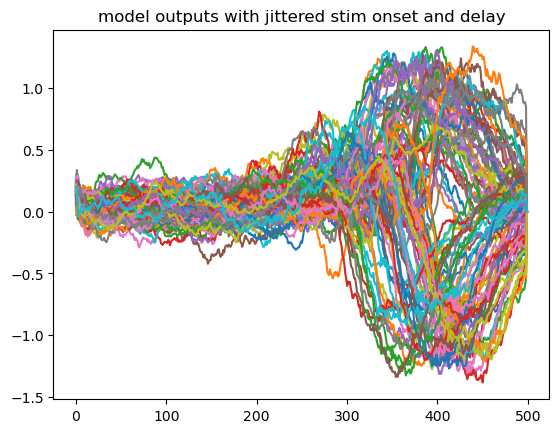

In [33]:
plt.figure()
plt.plot(np.array(outputs).T)
plt.title('model outputs with jittered stim onset and delay')
plt.show()

In [39]:
# delay 150

settings = {
        'T': 500, # trial duration (in steps)
        'stim_on': 100, # input stim onset (in steps)
        'stim_dur': 50, # input stim duration (in steps)
        'delay': 150, # delay b/w the two stimuli (in steps)
        'DeltaT': 1, # sampling rate
        'taus': 20, # decay time-constants (in steps)
        'task': 'xor', # task name
        }

outputs = []
perfs = np.zeros(100)
for i in range(100):
    jitter_onset = 50
    jitter_delay = 5
    settings_jitter = settings.copy()
    settings_jitter['stim_on'] = settings['stim_on'] + np.random.randint(-jitter_onset, jitter_onset+1)
    if jitter_delay > 0:
        settings_jitter['delay'] = settings['delay'] + np.random.randint(-jitter_delay, jitter_delay+1)

    u, label = generate_input_stim_xor(settings_jitter)
    _, _, o, _ = model.eval_tf(model_dir=f'{model_dir}/{model_fname}', settings=settings_jitter, u=u)
    outputs.append(o)

    resp_onset = settings_jitter['stim_on'] + 2*settings_jitter['stim_dur'] + settings_jitter['delay']
    eval_amp_threshold = 0.7
    if label == 'same':
        if np.max(o[resp_onset:]) > eval_amp_threshold:
            perfs[i] = 1
    else:
        if np.min(o[resp_onset:]) < -eval_amp_threshold:
            perfs[i] = 1
    

In [40]:
print(f'Performance with jittered stim onset and delay: {np.mean(perfs)*100:.2f}%')

Performance with jittered stim onset and delay: 60.00%


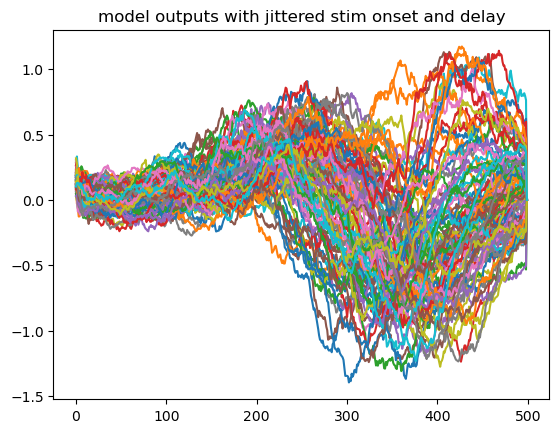

In [41]:
plt.figure()
plt.plot(np.array(outputs).T)
plt.title('model outputs with jittered stim onset and delay')
plt.show()

In [44]:
# delay 150

settings = {
        'T': 500, # trial duration (in steps)
        'stim_on': 200, # input stim onset (in steps)
        'stim_dur': 50, # input stim duration (in steps)
        'delay': 150, # delay b/w the two stimuli (in steps)
        'DeltaT': 1, # sampling rate
        'taus': 20, # decay time-constants (in steps)
        'task': 'xor', # task name
        }

outputs = []
perfs = np.zeros(100)
for i in range(100):
    jitter_onset = 50
    jitter_delay = 5

    u, label = generate_input_stim_xor(settings)
    _, _, o, _ = model.eval_tf(model_dir=f'{model_dir}/{model_fname}', settings=settings, u=u)
    outputs.append(o)

    resp_onset = settings['stim_on'] + 2*settings['stim_dur'] + settings['delay']
    eval_amp_threshold = 0.7
    if label == 'same':
        if np.max(o[resp_onset:]) > eval_amp_threshold:
            perfs[i] = 1
    else:
        if np.min(o[resp_onset:]) < -eval_amp_threshold:
            perfs[i] = 1

print(f'Performance with jittered stim onset and delay: {np.mean(perfs)*100:.2f}%')

Performance with jittered stim onset and delay: 53.00%


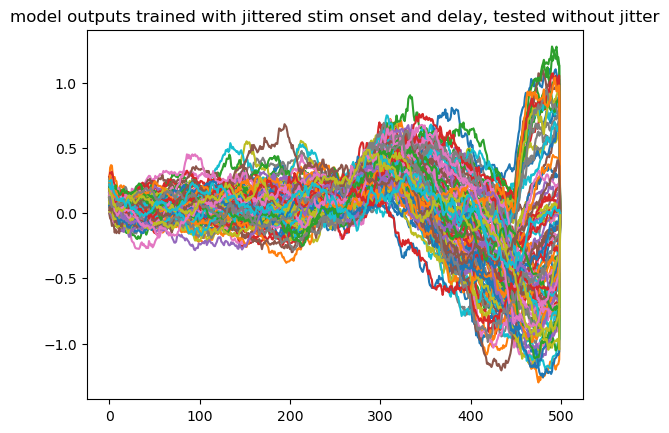

In [45]:
plt.figure()
plt.plot(np.array(outputs).T)
plt.title('model outputs trained with jittered stim onset and delay, tested without jitter')
plt.show()

### Trajectory plots

In [22]:

from sklearn.decomposition import PCA


In [27]:
r = np.squeeze(mat_data['r'])
r.shape

(500, 200)

X (r): time x neurons  

U: time x n_components  

S: n_components  

Vt: n_components x neurons  

In [29]:
# X = USVt

pca = PCA(n_components=3).fit(r)
r_U = pca.transform(r)
r_S = pca.singular_values_
r_Vt = pca.components_

print(r_U.shape)
print(r_S.shape)
print(r_Vt.shape)

(500, 3)
(3,)
(3, 200)


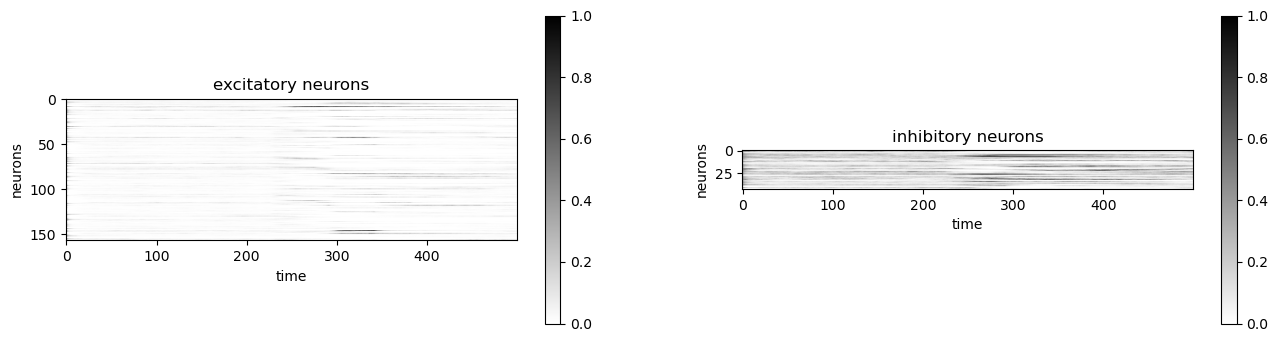

157 excitatory neurons
43 inhibitory neurons


In [30]:
fig,axs = plt.subplots(1,2,figsize=(16,4))
im1 = axs[0].imshow(r[:,exc_ind].T,cmap='binary',vmin=0, vmax=1)
axs[0].set_xlabel('time')
axs[0].set_ylabel('neurons')
axs[0].set_title('excitatory neurons')
fig.colorbar(im1)

im2 = axs[1].imshow(r[:,inh_ind].T,cmap='binary',vmin=0, vmax=1)
axs[1].set_xlabel('time')
axs[1].set_ylabel('neurons')
axs[1].set_title('inhibitory neurons')
fig.colorbar(im2)

plt.show()

print(f'{len(exc_ind)} excitatory neurons')
print(f'{len(inh_ind)} inhibitory neurons')